# <span style = 'font-family: Georgia'>Statistical Arbitrage Project </span>
***

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
from binance.client import Client as bnb_client
from scipy import stats

In [2]:
client = bnb_client(tld='US')

def get_binance_px(symbol,freq,start_ts = '2023-01-01',end_ts='2025-12-31'):
    data = client.get_historical_klines(symbol,freq,start_ts,end_ts)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']

    data = pd.DataFrame(data,columns = columns)
    
    # Convert from POSIX timestamp (number of millisecond since jan 1, 1970)
    data['open_time'] = pd.to_datetime(data['open_time'], unit='ms', utc=True)
    data['close_time'] = pd.to_datetime(data['close_time'], unit='ms', utc=True)
    return data 

tickers = ['BTCUSDT','ETHUSDT','ADAUSDT','BNBUSDT','SOLUSDT','DOGEUSDT','ZECUSDT','XLMUSDT','LINKUSDT','ADAUSDT',
           'LTCUSDT','AVAXUSDT','SHIBUSDT']
          

freq = '1d'
px = {}
for x in tickers:
    data = get_binance_px(x,freq)
    px[x] = data.set_index('open_time')['close']

px = pd.DataFrame(px).astype(float)
px = px.reindex(pd.date_range(px.index[0],px.index[-1],freq=freq))
px

,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,SOLUSDT,DOGEUSDT,ZECUSDT,XLMUSDT,LINKUSDT,LTCUSDT,AVAXUSDT,SHIBUSDT
2023-01-01 00:00:00+00:00,16617.57,1199.97,0.24989,244.1924,9.9994,0.070069,37.00,0.07251,5.62,70.69,10.87,0.000008
2023-01-02 00:00:00+00:00,16677.87,1214.05,0.25336,245.2174,11.2914,0.071352,39.40,0.07372,5.71,74.80,11.15,0.000008
2023-01-03 00:00:00+00:00,16674.12,1214.68,0.25297,246.0136,13.3944,0.070514,39.90,0.07377,5.59,75.52,11.37,0.000008
2023-01-04 00:00:00+00:00,16849.97,1256.89,0.26796,259.2094,13.4225,0.073260,40.50,0.07374,5.81,75.46,12.07,0.000008
2023-01-05 00:00:00+00:00,16832.48,1251.03,0.26891,256.5466,13.4253,0.071411,39.90,0.07286,5.65,74.06,11.75,0.000008
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27 00:00:00+00:00,87931.94,2950.40,0.36910,846.0100,124.6700,0.124270,515.18,0.22090,12.55,80.14,12.68,0.000007
2025-12-28 00:00:00+00:00,87724.87,2953.10,0.36840,857.9900,125.3400,0.123450,530.01,0.21970,12.36,78.45,12.61,0.000007
2025-12-29 00:00:00+00:00,87200.26,2939.50,0.35300,853.2600,123.2600,0.123040,543.85,0.21620,12.32,78.60,12.38,0.000007
2025-12-30 00:00:00+00:00,88432.11,2974.59,0.35150,859.8700,124.9900,0.123320,529.26,0.21110,12.40,78.56,12.57,0.000007


,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,SOLUSDT,DOGEUSDT,ZECUSDT,XLMUSDT,LINKUSDT,LTCUSDT,AVAXUSDT,SHIBUSDT
2023-01-02 00:00:00+00:00,0.003629,0.011734,0.013886,0.004198,0.129208,0.018313,0.064865,0.016687,0.016014,0.058141,0.025759,0.008610
2023-01-03 00:00:00+00:00,-0.000225,0.000519,-0.001539,0.003247,0.186248,-0.011753,0.012690,0.000678,-0.021016,0.009626,0.019731,-0.006098
2023-01-04 00:00:00+00:00,0.010546,0.034750,0.059256,0.053638,0.002098,0.038938,0.015038,-0.000407,0.039356,-0.000794,0.061566,0.026994
2023-01-05 00:00:00+00:00,-0.001038,-0.004662,0.003545,-0.010273,0.000209,-0.025229,-0.014815,-0.011934,-0.027539,-0.018553,-0.026512,0.000000
2023-01-06 00:00:00+00:00,0.007109,0.014724,0.037410,0.013540,0.006018,0.015254,0.032581,0.033763,0.007080,0.026060,0.000851,0.007168
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27 00:00:00+00:00,0.006797,0.006293,0.053368,0.012870,0.020380,0.016690,0.150726,0.027920,0.027005,0.034331,0.025061,0.032258
2025-12-28 00:00:00+00:00,-0.002355,0.000915,-0.001897,0.014161,0.005374,-0.006599,0.028786,-0.005432,-0.015139,-0.021088,-0.005521,-0.006793
2025-12-29 00:00:00+00:00,-0.005980,-0.004605,-0.041802,-0.005513,-0.016595,-0.003321,0.026113,-0.015931,-0.003236,0.001912,-0.018239,0.009576
2025-12-30 00:00:00+00:00,0.014127,0.011937,-0.004249,0.007747,0.014035,0.002276,-0.026827,-0.023589,0.006494,-0.000509,0.015347,-0.042005


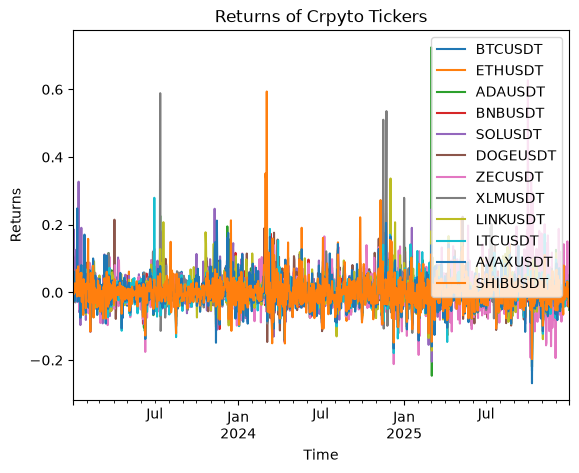

In [3]:
# Returns
ret = px / px.shift() -1
ret = ret.dropna()
ret
ret.plot(title = 'Returns of Crpyto Tickers', ylabel = 'Returns', xlabel = 'Time') 
ret

# <span style = 'font-family: Georgia'> Twenty-Day Rolling Momentum Strategy </span>
***

In [4]:
# Momentum Signal

# Because momentum is more prevelant in the longer term we will do in the past 30 days

# Momentum for First Strategy
momentum1 = ret.rolling(20,min_periods =1).mean()
momentum1 = momentum1.dropna()

# Signal Ranked for First Strategy
momrank1 = momentum1.rank(axis = 1)


# Signal Demeaned as it is a XS strategy

ranked1 = momentum1.rank(axis = 1)

demeaned1 = ranked1.sub(ranked1.mean(axis=1), axis=0)

# Then we normalize for the abs of weights to equal 1 

normw1 = demeaned1.div(demeaned1.abs().sum(axis=1), axis=0)
normw1



,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,SOLUSDT,DOGEUSDT,ZECUSDT,XLMUSDT,LINKUSDT,LTCUSDT,AVAXUSDT,SHIBUSDT
2023-01-02 00:00:00+00:00,-0.152778,-0.069444,-0.041667,-0.125000,0.152778,0.041667,0.125000,0.013889,-0.013889,0.097222,0.069444,-0.097222
2023-01-03 00:00:00+00:00,-0.097222,-0.013889,0.013889,-0.041667,0.152778,-0.069444,0.125000,0.041667,-0.152778,0.097222,0.069444,-0.125000
2023-01-04 00:00:00+00:00,-0.152778,-0.013889,0.069444,0.013889,0.152778,-0.041667,0.097222,-0.125000,-0.069444,0.041667,0.125000,-0.097222
2023-01-05 00:00:00+00:00,-0.097222,-0.013889,0.069444,0.041667,0.152778,-0.069444,0.097222,-0.152778,-0.125000,0.013889,0.125000,-0.041667
2023-01-06 00:00:00+00:00,-0.125000,-0.013889,0.125000,0.013889,0.152778,-0.097222,0.097222,-0.041667,-0.152778,0.041667,0.069444,-0.069444
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27 00:00:00+00:00,0.097222,0.069444,-0.125000,0.013889,-0.013889,-0.097222,0.152778,-0.041667,-0.069444,0.125000,0.041667,-0.152778
2025-12-28 00:00:00+00:00,0.125000,0.069444,-0.125000,0.097222,0.041667,-0.097222,0.152778,-0.041667,-0.069444,-0.013889,0.013889,-0.152778
2025-12-29 00:00:00+00:00,0.097222,0.013889,-0.152778,0.125000,0.041667,-0.125000,0.152778,-0.041667,-0.013889,0.069444,-0.069444,-0.097222
2025-12-30 00:00:00+00:00,0.097222,0.013889,-0.152778,0.125000,0.041667,-0.069444,0.152778,-0.097222,-0.041667,0.069444,-0.013889,-0.125000


In [62]:
# Unconstrained Backtest

# Portfolio Returns for First Strategy

portret1 = (normw1 *ret.shift(-1)).sum(axis = 1)


<Axes: >

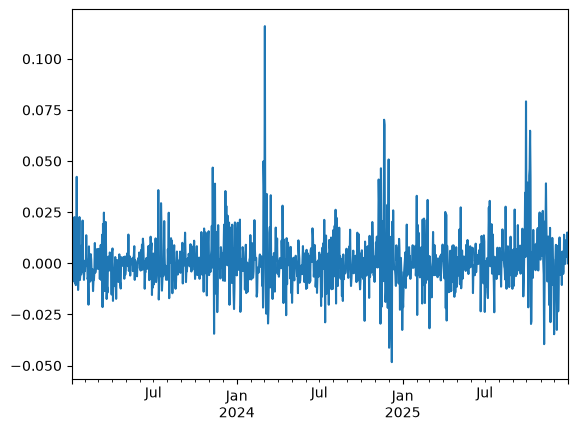

In [63]:
# First Strategies, return plot

portret1.plot()

In [71]:
# Annualized Stats
ret1 = float(portret1.mean() * 365)
vol1 = float(portret1.std() * np.sqrt(365)) # The crypto market is opened 365 times a year unlike the stock market which is only 252 days
sr1 = ret1 / vol1

stats1 = pd.Series([ret1, vol1, sr1],index=["Ann_ret", "Ann_vol", "Ann_sharpe"])
stats1 = stats1.rename_axis("Annualized Statistics for Twenty-Day Rolling Momentum Strategy")

stats1

Annualized Statistics for Twenty-Day Rolling Momentum Strategy
Ann_ret       0.397135
Ann_vol       0.247046
Ann_sharpe    1.607531
dtype: float64

# <span style= 'font-family: "Georgia"' > Monmentum Seasonalitt Strategy </span>
***

In [8]:
# Finding the average returns per month in a 3 year period
# Second Strategy

retmmean = ret.groupby(ret.index.month).mean()
retmmean

,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,SOLUSDT,DOGEUSDT,ZECUSDT,XLMUSDT,LINKUSDT,LTCUSDT,AVAXUSDT,SHIBUSDT
1,0.004995,0.003405,0.005086,0.002122,0.013353,0.003277,-0.002200,0.004034,0.006003,0.005350,0.005964,0.001932
2,0.002267,0.000526,-0.001944,0.001739,-0.002297,-0.002186,0.001921,-0.003107,-0.002418,0.002724,-0.003510,0.001545
3,0.004309,0.000958,0.005048,0.006049,0.004482,0.006332,0.001805,0.004565,0.000833,-0.000854,0.003210,0.010862
4,0.000309,-0.001331,-0.003210,0.000308,-0.001441,-0.003528,-0.004853,-0.004020,-0.003476,-0.002458,-0.003603,-0.002675
5,0.001744,0.006827,0.000106,0.000394,0.003095,0.002977,0.006306,-0.000465,0.003128,0.001627,-0.000331,0.000008
6,0.000921,-0.000496,-0.005958,-0.002556,-0.001750,-0.004723,-0.004857,-0.000447,-0.002968,0.001658,-0.004123,-0.006441
7,0.000822,0.003478,0.004321,0.002101,0.006203,0.005030,0.005137,0.012599,0.004183,0.000181,0.001531,0.001989
8,-0.002616,-0.001347,-0.001659,-0.000666,-0.002050,-0.003080,-0.000502,-0.004507,0.000300,-0.003724,-0.002647,-0.001528
9,0.001909,0.000152,0.001080,0.002532,0.003163,0.002402,0.006747,0.001002,0.004055,0.000732,0.004691,0.002006
10,0.003659,0.000180,-0.001702,0.002113,0.007166,0.003481,0.026466,-0.001284,0.001939,0.000272,-0.003142,-0.000207


In [10]:
from scipy import stats
zscores = stats.zscore(retmmean)
zscoresdf = pd.DataFrame(zscores, index =retmmean.index, columns = retmmean.columns)

zscoresdf

,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,SOLUSDT,DOGEUSDT,ZECUSDT,XLMUSDT,LINKUSDT,LTCUSDT,AVAXUSDT,SHIBUSDT
1,1.634378,0.875824,0.797100,0.277235,2.226663,0.370001,-0.771540,0.281531,1.357765,1.869340,0.990545,0.259639
2,0.232819,-0.353586,-0.672122,0.105299,-1.247626,-0.760345,-0.256556,-0.685616,-1.279213,0.777315,-0.980708,0.162968
3,1.282048,-0.168983,0.789157,2.037532,0.257308,1.002120,-0.271090,0.353467,-0.261161,-0.710646,0.417571,2.491611
4,-0.773426,-1.146178,-0.936659,-0.536471,-1.057583,-1.037894,-1.102953,-0.809257,-1.610225,-1.378014,-0.999974,-0.891804
5,-0.035677,2.337055,-0.243593,-0.497883,-0.050664,0.307930,0.291375,-0.327673,0.457340,0.320990,-0.319166,-0.221187
6,-0.458925,-0.789957,-1.510974,-1.820501,-1.126340,-1.285163,-1.103472,-0.325240,-1.451191,0.333867,-1.108204,-1.833085
7,-0.509836,0.907137,0.637417,0.267741,0.639305,0.732665,0.145289,1.441578,0.787817,-0.280348,0.068196,0.273944
8,-2.276183,-1.153021,-0.612439,-0.972886,-1.192962,-0.945312,-0.559392,-0.875204,-0.428132,-1.904500,-0.801081,-0.605270
9,0.049045,-0.513201,-0.039981,0.460706,-0.035537,0.188958,0.346431,-0.129017,0.747838,-0.051392,0.725632,0.278132
10,0.947944,-0.501028,-0.621576,0.273062,0.853158,0.412306,2.810379,-0.438671,0.085118,-0.242532,-0.904134,-0.274878


In [11]:
filtered_returns2 = retmmean.mask(zscoresdf > 1.5).mask(zscoresdf < -1.5)

ranked_returns2 = filtered_returns2.rank(axis = 0)
centered_rank2 = ranked_returns2.rank(axis=0) -ranked_returns2.rank(axis=0).mean()

weight2 = centered_rank2.div(centered_rank2.abs().sum(axis=1), axis=0)
weight2

,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,SOLUSDT,DOGEUSDT,ZECUSDT,XLMUSDT,LINKUSDT,LTCUSDT,AVAXUSDT,SHIBUSDT
1,NaN,0.105263,0.157895,0.087719,NaN,0.070175,-0.105263,0.105263,0.140351,NaN,0.175439,0.052632
2,0.058824,0.039216,-0.137255,-0.019608,-0.196078,-0.039216,0.000000,-0.078431,-0.156863,0.137255,-0.117647,0.019608
3,0.152542,0.067797,0.118644,NaN,0.067797,0.169492,-0.033898,0.135593,-0.067797,-0.118644,0.067797,NaN
4,-0.111111,-0.098765,-0.111111,-0.061728,-0.049383,-0.074074,-0.098765,-0.074074,NaN,-0.111111,-0.098765,-0.111111
5,-0.047619,NaN,-0.047619,-0.142857,-0.095238,0.095238,0.285714,0.000000,0.095238,0.142857,0.000000,-0.047619
6,-0.048387,-0.096774,NaN,NaN,-0.096774,-0.161290,-0.161290,0.032258,-0.161290,0.080645,-0.161290,NaN
7,-0.076923,0.123077,0.076923,0.015385,0.092308,0.123077,0.061538,0.153846,0.092308,-0.076923,0.030769,0.076923
8,NaN,-0.163934,-0.049180,-0.147541,-0.131148,-0.065574,-0.065574,-0.131148,-0.098361,NaN,-0.032787,-0.114754
9,0.022222,-0.088889,0.022222,0.155556,0.000000,0.000000,0.177778,0.088889,0.088889,-0.022222,0.177778,0.155556
10,0.148936,-0.042553,-0.106383,0.063830,0.212766,0.127660,NaN,-0.042553,-0.042553,-0.063830,-0.085106,-0.063830


In [65]:
month_weights = weight2.loc[ret.index.month]  # align weights by month
month_weights.index = ret.index              # restore datetime index

portret2 = (month_weights * ret).sum(axis=1).dropna()
portret2

2023-01-02 00:00:00+00:00    0.007230
2023-01-03 00:00:00+00:00   -0.001802
2023-01-04 00:00:00+00:00    0.036571
2023-01-05 00:00:00+00:00   -0.010816
2023-01-06 00:00:00+00:00    0.011360
                               ...   
2025-12-27 00:00:00+00:00    0.003420
2025-12-28 00:00:00+00:00    0.005536
2025-12-29 00:00:00+00:00   -0.001578
2025-12-30 00:00:00+00:00    0.008524
2025-12-31 00:00:00+00:00    0.014110
Freq: D, Length: 1095, dtype: float64

<Axes: >

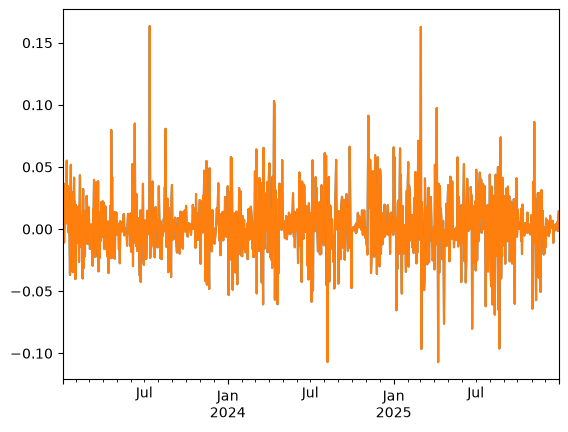

In [66]:
# Portfolio Returns Plotted

portret2.plot()

portret2.plot()

In [72]:
# Annualized Statistics

ret2 = float(portret2.mean() * 365)
vol2 = float(portret2.std() * np.sqrt(365))
sr2 = ret2 / vol2

stats2 = pd.Series([ret2, vol2, sr2],index=["Ann_ret", "Ann_vol", "Ann_sharpe"])
stats2 = stats2.rename_axis("Annualized Statistics for Seasonality Momentum Strategy")

stats2

Annualized Statistics for Seasonality Momentum Strategy
Ann_ret       1.172533
Ann_vol       0.478237
Ann_sharpe    2.451781
dtype: float64

# Vix Macro Correlation with Reversal Strategy
***

In [15]:
# Third Strategy

rankedreverse3 = ret.rank(axis = 1) - (ret.rank(axis = 1).mean(axis = 1).mean())
rankedreverse3.dropna()
normalized_weights3 = rankedreverse3 / float(rankedreverse3.abs().sum(axis = 1).mean().mean())
normalized_weights3 * -1

,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,SOLUSDT,DOGEUSDT,ZECUSDT,XLMUSDT,LINKUSDT,LTCUSDT,AVAXUSDT,SHIBUSDT
2023-01-02 00:00:00+00:00,0.152778,0.069444,0.041667,0.125000,-0.152778,-0.041667,-0.125000,-0.013889,0.013889,-0.097222,-0.069444,0.097222
2023-01-03 00:00:00+00:00,0.041667,0.013889,0.069444,-0.041667,-0.152778,0.125000,-0.097222,-0.013889,0.152778,-0.069444,-0.125000,0.097222
2023-01-04 00:00:00+00:00,0.069444,-0.013889,-0.125000,-0.097222,0.097222,-0.041667,0.041667,0.125000,-0.069444,0.152778,-0.152778,0.013889
2023-01-05 00:00:00+00:00,-0.069444,-0.041667,-0.152778,-0.013889,-0.125000,0.097222,0.041667,0.013889,0.152778,0.069444,0.125000,-0.097222
2023-01-06 00:00:00+00:00,0.069444,-0.013889,-0.152778,0.013889,0.125000,-0.041667,-0.097222,-0.125000,0.097222,-0.069444,0.152778,0.041667
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27 00:00:00+00:00,0.125000,0.152778,-0.125000,0.097222,0.041667,0.069444,-0.152778,-0.041667,-0.013889,-0.097222,0.013889,-0.069444
2025-12-28 00:00:00+00:00,-0.013889,-0.069444,-0.041667,-0.125000,-0.097222,0.069444,-0.152778,0.013889,0.125000,0.152778,0.041667,0.097222
2025-12-29 00:00:00+00:00,0.041667,-0.013889,0.152778,0.013889,0.097222,-0.041667,-0.152778,0.069444,-0.069444,-0.097222,0.125000,-0.125000
2025-12-30 00:00:00+00:00,-0.125000,-0.069444,0.069444,-0.041667,-0.097222,0.013889,0.125000,0.097222,-0.013889,0.041667,-0.152778,0.152778


##### Because in reversal we want to take the opposite weights of a momenutm strategy we are going to multiply our weights by a negative 1

In [78]:
indv_portret_3 = normalized_weights3.shift(1) * ret
indv_portret_3.index = pd.to_datetime(indv_portret_3.index).tz_localize(None).normalize()

portret3 =indv_portret_3.sum(axis = 1, min_count = 1)
portret3.name = ('Portfolio Returns')
portret3

2023-01-02         NaN
2023-01-03    0.032408
2023-01-04   -0.006889
2023-01-05   -0.002639
2023-01-06    0.002153
                ...   
2025-12-27    0.011799
2025-12-28    0.000291
2025-12-29   -0.000064
2025-12-30   -0.010379
2025-12-31    0.012176
Freq: D, Name: Portfolio Returns, Length: 1095, dtype: float64

In [79]:
ret3 = float(portret3.mean() * 365)
vol3 = float(portret3.std() * np.sqrt(365))
sr3 = ret3 / vol3

stats3 = pd.Series([ret3, vol3, sr3],index=["Ann_ret", "Ann_vol", "Ann_sharpe"])
stats3 = stats3.rename_axis("Annualized Statistics for Reversal Strategy")
stats3

Annualized Statistics for Reversal Strategy
Ann_ret       0.055462
Ann_vol       0.240267
Ann_sharpe    0.230835
dtype: float64

# Strategy Statistics Before Weighting and Finished Backtest
***

In [98]:
returns = {'Twenty Day Momentum': ret1, 'Monthly Weighted Momentum': ret2, 'Reversal Strategy': ret3}
volatility = {'Twenty Day Momentum': vol1, 'Monthly Weighted Momentum': vol2, 'Reversal Strategy': vol3}
sharpes = {'Twenty Day Momentum': sr1, 'Monthly Weighted Momentum': sr2, 'Reversal Strategy': sr3}

In [105]:
stats_before = pd.DataFrame({'Returns': returns, 'Volatility': volatility, 'Sharpe': sharpes})
stats_before

,Returns,Volatility,Sharpe
Twenty Day Momentum,0.397135,0.247046,1.607531
Monthly Weighted Momentum,1.172533,0.478237,2.451781
Reversal Strategy,0.055462,0.240267,0.230835


## Weighting

In [140]:
def sr_weights(sigma,mu): # Using sharpe ratio proportional weights
    wgt = mu / np.diag(sigma) 
    wgt = wgt / np.abs(wgt).sum()
    return wgt

In [141]:
p1 = portret1.copy()
p2 = portret2.copy()
p3 = portret3.copy()

for p in [p1, p2, p3]:
    p.index = pd.to_datetime(p.index, utc=True).tz_localize(None).normalize() # Utilized AI for this code, was stuck on timezone bug

portfolio_returns = pd.concat(
    [p1, p2, p3],
    axis=1,
    keys=["Twenty Day Momentum", "Monthly Weighted Momentum", "Reversal Strategy"]
)

sigma = portfolio_returns.cov() # Generating historical covariance matrix
sigma

,Twenty Day Momentum,Monthly Weighted Momentum,Reversal Strategy
Twenty Day Momentum,0.000167,-0.000013,0.000001
Monthly Weighted Momentum,-0.000013,0.000627,0.000034
Reversal Strategy,0.000001,0.000034,0.000158


In [142]:
corr = portfolio_returns.corr() # Sort of a normalized version of the covariance matrix
corr

,Twenty Day Momentum,Monthly Weighted Momentum,Reversal Strategy
Twenty Day Momentum,1.000000,-0.038984,0.008328
Monthly Weighted Momentum,-0.038984,1.000000,0.107199
Reversal Strategy,0.008328,0.107199,1.000000


In [143]:
mu = portfolio_returns.mean()
mu

Twenty Day Momentum          0.001088
Monthly Weighted Momentum    0.003212
Reversal Strategy            0.000152
dtype: float64

In [183]:
weights = {}

# Going to use sharpe ratio proportional weights 
weights['sr'] = sr_weights(sigma,mu)
weights = pd.DataFrame([sr_weights(sigma, mu)], index=["Weight"], columns = portfolio_returns.columns).round(2)
weights

,Twenty Day Momentum,Monthly Weighted Momentum,Reversal Strategy
Weight,0.52,0.41,0.08


In [189]:
#  Take the dot product of the portfolio returns and the weights of the strategies to get the sharpe

combo_rets = portfolio_returns @ weights.loc["Weight"] 
combo_sr = (combo_rets.mean() / combo_rets.std() * np.sqrt(365))
float(combo_sr)

2.9468317113859066

### The weighted Sharpe is 2.94 this is before execution and checking for overfit

# Execution